# Restaurant Analytics & Business Insights

## 1. Project Title & Executive Summary

This project analyzes 9,551 restaurant records to identify patterns in market concentration, cuisine preferences, pricing, customer engagement, digital service adoption, geographic distribution, and restaurant-chain performance.

Key findings include:

- North Indian, Chinese and Fast Food are the three most prevalent cuisines.
- The top three cities account for 80.39% of restaurant records.
- Price Range 1 and 2 together represent 79.13% of restaurants.
- Price range is positively associated with both ratings and customer
  engagement, with stronger engagement differences across price segments.
- Online delivery is available at 25.69% of restaurants, while table booking
  is available at 12.14%.
- Table booking is substantially more prevalent among higher-priced
  restaurants, whereas online delivery does not follow a linear price pattern.
- Restaurant chain scale has only a weak association with average rating.
- Among rated restaurants, votes and ratings show a moderate positive
  association (r = 0.409).

The analysis combines exploratory data analysis, segmentation, correlation
analysis and non-parametric statistical testing to translate restaurant
data into actionable market insights.

## 2. Business Problem & Objectives

The restaurant industry generates large volumes of customer, pricing,
location, and service data. However, raw restaurant-level data does not
directly reveal which cuisines dominate the market, how pricing relates to
customer ratings, where restaurants are geographically concentrated, or
whether digital service capabilities are associated with customer engagement.

This project analyzes restaurant-level data to identify market patterns,
customer-rating relationships, pricing trends, service adoption patterns,
and characteristics of multi-location restaurant brands.

### Objectives

- Identify dominant cuisines and their customer-rating patterns
- Understand geographic concentration across cities
- Examine the relationship between price positioning and ratings
- Analyze customer engagement through restaurant votes
- Evaluate online delivery and table-booking adoption
- Examine multi-location restaurant brand performance
- Statistically validate selected relationships
- Translate analytical findings into actionable business insights

In [35]:
import pandas as pd

df = pd.read_csv("/content/Dataset.csv")

print(f"Dataset contains {df.shape[0]:,} rows and {df.shape[1]} columns.")

Dataset contains 9,551 rows and 21 columns.


In [36]:
df.head()


,Restaurant ID,Restaurant Name,Country Code,City,Address,Locality,Locality Verbose,Longitude,Latitude,Cuisines,...,Currency,Has Table booking,Has Online delivery,Is delivering now,Switch to order menu,Price range,Aggregate rating,Rating color,Rating text,Votes
0,6317637,Le Petit Souffle,162,Makati City,"Third Floor, Century City Mall, Kalayaan Avenu...","Century City Mall, Poblacion, Makati City","Century City Mall, Poblacion, Makati City, Mak...",121.027535,14.565443,"French, Japanese, Desserts",...,Botswana Pula(P),Yes,No,No,No,3,4.8,Dark Green,Excellent,314
1,6304287,Izakaya Kikufuji,162,Makati City,"Little Tokyo, 2277 Chino Roces Avenue, Legaspi...","Little Tokyo, Legaspi Village, Makati City","Little Tokyo, Legaspi Village, Makati City, Ma...",121.014101,14.553708,Japanese,...,Botswana Pula(P),Yes,No,No,No,3,4.5,Dark Green,Excellent,591
2,6300002,Heat - Edsa Shangri-La,162,Mandaluyong City,"Edsa Shangri-La, 1 Garden Way, Ortigas, Mandal...","Edsa Shangri-La, Ortigas, Mandaluyong City","Edsa Shangri-La, Ortigas, Mandaluyong City, Ma...",121.056831,14.581404,"Seafood, Asian, Filipino, Indian",...,Botswana Pula(P),Yes,No,No,No,4,4.4,Green,Very Good,270
3,6318506,Ooma,162,Mandaluyong City,"Third Floor, Mega Fashion Hall, SM Megamall, O...","SM Megamall, Ortigas, Mandaluyong City","SM Megamall, Ortigas, Mandaluyong City, Mandal...",121.056475,14.585318,"Japanese, Sushi",...,Botswana Pula(P),No,No,No,No,4,4.9,Dark Green,Excellent,365
4,6314302,Sambo Kojin,162,Mandaluyong City,"Third Floor, Mega Atrium, SM Megamall, Ortigas...","SM Megamall, Ortigas, Mandaluyong City","SM Megamall, Ortigas, Mandaluyong City, Mandal...",121.057508,14.584450,"Japanese, Korean",...,Botswana Pula(P),Yes,No,No,No,4,4.8,Dark Green,Excellent,229


## 3. Dataset Overview and Data Quality

In [37]:
print(f"Number of rows: {df.shape[0]:,}")
print(f"Number of columns: {df.shape[1]:,}")

Number of rows: 9,551
Number of columns: 21


In [38]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9551 entries, 0 to 9550
Data columns (total 21 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Restaurant ID         9551 non-null   int64  
 1   Restaurant Name       9551 non-null   object 
 2   Country Code          9551 non-null   int64  
 3   City                  9551 non-null   object 
 4   Address               9551 non-null   object 
 5   Locality              9551 non-null   object 
 6   Locality Verbose      9551 non-null   object 
 7   Longitude             9551 non-null   float64
 8   Latitude              9551 non-null   float64
 9   Cuisines              9542 non-null   object 
 10  Average Cost for two  9551 non-null   int64  
 11  Currency              9551 non-null   object 
 12  Has Table booking     9551 non-null   object 
 13  Has Online delivery   9551 non-null   object 
 14  Is delivering now     9551 non-null   object 
 15  Switch to order menu 

In [39]:
missing_values = df.isnull().sum()

missing_summary = (
    pd.DataFrame({
        "Missing Values": missing_values,
        "Missing %": (missing_values / len(df) * 100).round(2)
    })
    .sort_values("Missing Values", ascending=False)
)

missing_summary[missing_summary["Missing Values"] > 0]

,Missing Values,Missing %
Cuisines,9,0.09


In [40]:
df[df["Cuisines"].isna()]

,Restaurant ID,Restaurant Name,Country Code,City,Address,Locality,Locality Verbose,Longitude,Latitude,Cuisines,...,Currency,Has Table booking,Has Online delivery,Is delivering now,Switch to order menu,Price range,Aggregate rating,Rating color,Rating text,Votes
84,17284105,Cookie Shoppe,216,Albany,"115 N Jackson St, Albany, GA 31701",Albany,"Albany, Albany",-84.154000,31.577200,NaN,...,Dollar($),No,No,No,No,1,3.4,Orange,Average,34
87,17284211,Pearly's Famous Country Cookng,216,Albany,"814 N Slappey Blvd, Albany, GA 31701",Albany,"Albany, Albany",-84.175900,31.588200,NaN,...,Dollar($),No,No,No,No,1,3.4,Orange,Average,36
94,17284158,Jimmie's Hot Dogs,216,Albany,"204 S Jackson St, Albany, GA 31701",Albany,"Albany, Albany",-84.153400,31.575100,NaN,...,Dollar($),No,No,No,No,1,3.9,Yellow,Good,160
297,17374552,Corkscrew Cafe,216,Gainesville,"51 W Main St, Dahlonega, GA 30533",Dahlonega,"Dahlonega, Gainesville",-83.985800,34.531800,NaN,...,Dollar($),No,No,No,No,3,3.9,Yellow,Good,209
328,17501439,Dovetail,216,Macon,"543 Cherry St, Macon, GA 31201",Macon,"Macon, Macon",-83.627979,32.836410,NaN,...,Dollar($),No,No,No,No,3,3.8,Yellow,Good,102
346,17606621,HI Lite Bar & Lounge,216,Miller,"109 N Broadway Ave, Miller, SD 57362",Miller,"Miller, Miller",-98.989100,44.515800,NaN,...,Dollar($),No,No,No,No,1,3.4,Orange,Average,11
368,17059060,Hillstone,216,Orlando,"215 South Orlando Avenue, Winter Park, FL 32789",Winter Park,"Winter Park, Orlando",-81.365260,28.596682,NaN,...,Dollar($),No,No,No,No,3,4.4,Green,Very Good,1158
418,17142698,Leonard's Bakery,216,Rest of Hawaii,"933 Kapahulu Ave, Honolulu, HI 96816",Kaimuki,"Kaimuki, Rest of Hawaii",-157.813432,21.284586,NaN,...,Dollar($),No,No,No,No,1,4.7,Dark Green,Excellent,707
455,17616465,Tybee Island Social Club,216,Savannah,"1311 Butler Ave, Tybee Island, GA 31328",Tybee Island,"Tybee Island, Savannah",-80.848297,31.995810,NaN,...,Dollar($),No,No,No,No,1,3.9,Yellow,Good,309


In [122]:
missing_cuisines = df["Cuisines"].isna().sum()

print(f"Restaurants with missing cuisine information: {missing_cuisines}")

df = df.dropna(subset=["Cuisines"]).copy()

Restaurants with missing cuisine information: 0


In [42]:
duplicate_count = df.duplicated().sum()

print(f"Duplicate rows: {duplicate_count:,}")

Duplicate rows: 0


In [43]:
df.dtypes

,0
Restaurant ID,int64
Restaurant Name,object
Country Code,int64
City,object
Address,object
Locality,object
Locality Verbose,object
Longitude,float64
Latitude,float64
Cuisines,object


In [44]:
df[[
    "Average Cost for two",
    "Price range",
    "Aggregate rating",
    "Votes",
    "Latitude",
    "Longitude"
]].describe().T

,count,mean,std,min,25%,50%,75%,max
Average Cost for two,9542.0,1200.326137,16128.743876,0.000000,250.000000,400.000000,700.000000,800000.000000
Price range,9542.0,1.804968,0.905563,1.000000,1.000000,2.000000,2.000000,4.000000
Aggregate rating,9542.0,2.665238,1.516588,0.000000,2.500000,3.200000,3.700000,4.900000
Votes,9542.0,156.772060,430.203324,0.000000,5.000000,31.000000,130.000000,10934.000000
Latitude,9542.0,25.848532,11.010094,-41.330428,28.478658,28.570444,28.642711,55.976980
Longitude,9542.0,64.274997,41.197602,-157.948486,77.081565,77.192031,77.282043,174.832089


In [45]:
df.nlargest(10, "Average Cost for two")[
    [
        "Restaurant Name",
        "City",
        "Country Code",
        "Average Cost for two",
        "Currency",
        "Price range",
        "Aggregate rating"
    ]
]

,Restaurant Name,City,Country Code,Average Cost for two,Currency,Price range,Aggregate rating
9283,Skye,Jakarta,94,800000,Indonesian Rupiah(IDR),3,4.1
9284,Satoo - Hotel Shangri-La,Jakarta,94,800000,Indonesian Rupiah(IDR),3,4.6
9287,Sushi Masa,Jakarta,94,500000,Indonesian Rupiah(IDR),3,4.9
9289,3 Wise Monkeys,Jakarta,94,450000,Indonesian Rupiah(IDR),3,4.2
9294,Avec Moi Restaurant and Bar,Jakarta,94,350000,Indonesian Rupiah(IDR),3,4.3
9288,Lucky Cat Coffee & Kitchen,Jakarta,94,300000,Indonesian Rupiah(IDR),3,4.3
9295,Onokabe,Tangerang,94,300000,Indonesian Rupiah(IDR),3,3.7
9278,Lemongrass,Bogor,94,250000,Indonesian Rupiah(IDR),3,4.0
9285,MONKS,Jakarta,94,250000,Indonesian Rupiah(IDR),3,4.2
9279,Talaga Sampireun,Jakarta,94,200000,Indonesian Rupiah(IDR),3,4.9


In [46]:
df["Currency"].value_counts()

,count
Currency,
Indian Rupees(Rs.),8652
Dollar($),473
Pounds(��),80
Brazilian Real(R$),60
Rand(R),60
Emirati Diram(AED),60
NewZealand($),40
Turkish Lira(TL),34
Botswana Pula(P),22


In [47]:
df["Aggregate rating"].value_counts().sort_index()

,count
Aggregate rating,
0.0,2148
1.8,1
1.9,2
2.0,7
2.1,15
2.2,27
2.3,47
2.4,87
2.5,110


## 4. Data Cleaning and Feature Engineering

In [48]:
import numpy as np

# Preserve the original rating values and exclude unrated restaurants
# from rating-based calculations.

df["Rating for Analysis"] = df["Aggregate rating"].replace(0, np.nan)

print("Restaurants with no recorded rating:",
      df["Rating for Analysis"].isna().sum())

print("Restaurants with recorded rating:",
      df["Rating for Analysis"].notna().sum())

Restaurants with no recorded rating: 2148
Restaurants with recorded rating: 7394


Rating Data Treatment: Aggregate rating values of 0.0 are treated as unrated observations and excluded from rating-based statistical calculations.

## 5. Exploratory Data Analysis (EDA)

This section examines restaurant performance across five key dimensions: ratings and customer engagement, cuisine preferences, geographic concentration, pricing, and digital service adoption. The analysis combines descriptive statistics, visual exploration, correlation analysis, and hypothesis testing to translate restaurant-level data into actionable business insights.

In [50]:
overview = pd.DataFrame({
    "Metric": [
        "Total Restaurants",
        "Total Cities",
        "Total Countries",
        "Average Rating",
        "Average Votes",
        "Restaurants with Online Delivery"
    ],
    "Value": [
        df["Restaurant ID"].nunique(),
        df["City"].nunique(),
        df["Country Code"].nunique(),
        round(df["Rating for Analysis"].mean(), 2),
        round(df["Votes"].mean(), 2),
        (df["Has Online delivery"] == "Yes").sum()
    ]
})

overview

,Metric,Value
0,Total Restaurants,9542.00
1,Total Cities,140.00
2,Total Countries,15.00
3,Average Rating,3.44
4,Average Votes,156.77
5,Restaurants with Online Delivery,2451.00


In [51]:
delivery_percentage = (
    df["Has Online delivery"].eq("Yes").mean() * 100
)

print(f"Restaurants offering online delivery: {delivery_percentage:.2f}%")

Restaurants offering online delivery: 25.69%


### 5.1 Restaurant Rating Distribution

### Rating Data Quality Note

A total of 2,148 restaurants have an aggregate rating of 0.0. These records are treated as **Not Rated** rather than as genuine zero-star ratings for rating-based analysis. This prevents unrated restaurants from artificially lowering average rating calculations.

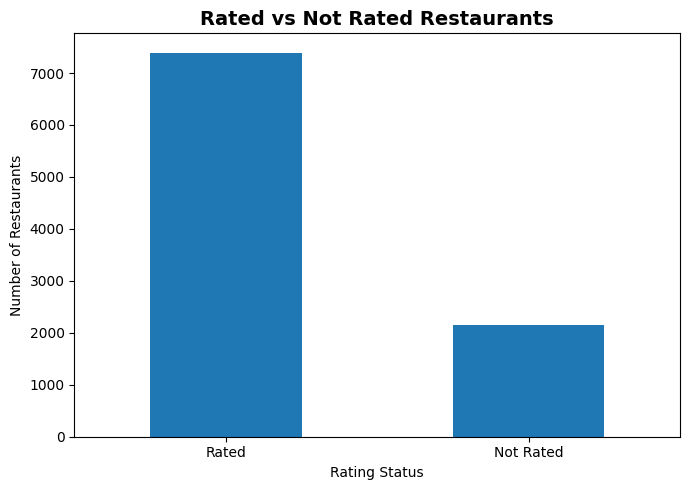

In [134]:
# Rated vs Not Rated restaurants

rating_status = df["Aggregate rating"].apply(
    lambda x: "Not Rated" if x == 0 else "Rated"
).value_counts()

plt.figure(figsize=(7, 5))

rating_status.plot(kind="bar")

plt.title(
    "Rated vs Not Rated Restaurants",
    fontsize=14,
    fontweight="bold"
)

plt.xlabel("Rating Status")
plt.ylabel("Number of Restaurants")

plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

**Business Insight:**  
Approximately 22.5% of restaurants in the dataset are not rated, indicating a meaningful coverage gap in customer feedback. Therefore, rating-based comparisons should focus on rated restaurants rather than treating a 0.0 rating as a genuine customer evaluation.

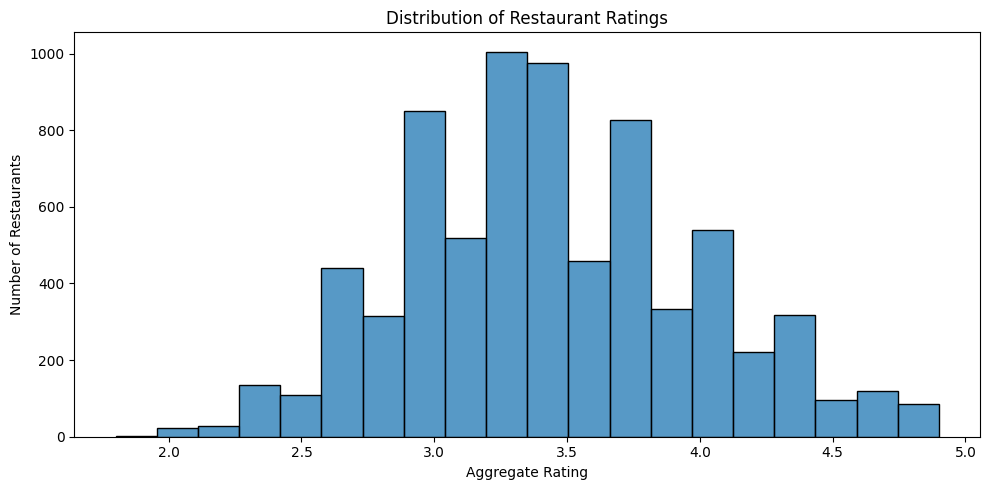

In [52]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 5))

sns.histplot(
    data=df,
    x="Rating for Analysis",
    bins=20
)

plt.title("Distribution of Restaurant Ratings")
plt.xlabel("Aggregate Rating")
plt.ylabel("Number of Restaurants")
plt.tight_layout()
plt.show()

In [53]:
rating_status = pd.Series({
    "Rated": df["Rating for Analysis"].notna().sum(),
    "Not Rated": df["Rating for Analysis"].isna().sum()
})

rating_status

,0
Rated,7394
Not Rated,2148


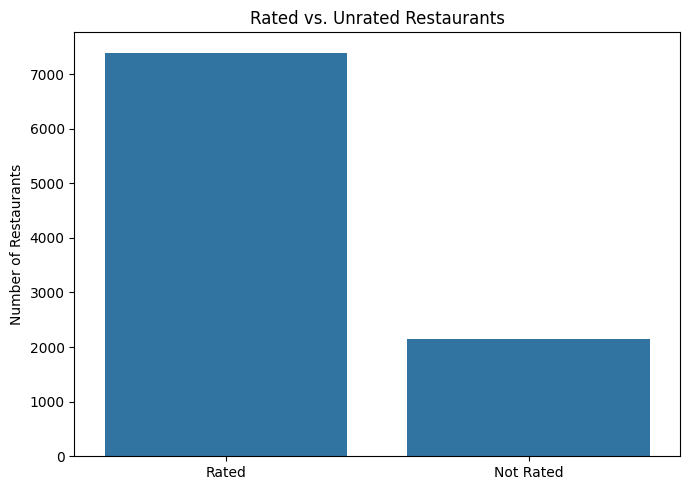

In [54]:
plt.figure(figsize=(7, 5))

sns.barplot(
    x=rating_status.index,
    y=rating_status.values
)

plt.title("Rated vs. Unrated Restaurants")
plt.xlabel("")
plt.ylabel("Number of Restaurants")
plt.tight_layout()
plt.show()

### 5.2 Cuisine Analysis

In [55]:
# Create a separate row for each cuisine listed for a restaurant

cuisine_df = df[["Restaurant ID", "Cuisines"]].copy()

cuisine_df["Cuisines"] = cuisine_df["Cuisines"].str.split(",")

cuisine_df = cuisine_df.explode("Cuisines")

cuisine_df["Cuisines"] = cuisine_df["Cuisines"].str.strip()

cuisine_counts = (
    cuisine_df["Cuisines"]
    .value_counts()
    .reset_index()
)

cuisine_counts.columns = ["Cuisine", "Restaurant Count"]

cuisine_counts.head(10)

,Cuisine,Restaurant Count
0,North Indian,3960
1,Chinese,2735
2,Fast Food,1986
3,Mughlai,995
4,Italian,764
5,Bakery,745
6,Continental,736
7,Cafe,703
8,Desserts,653
9,South Indian,636


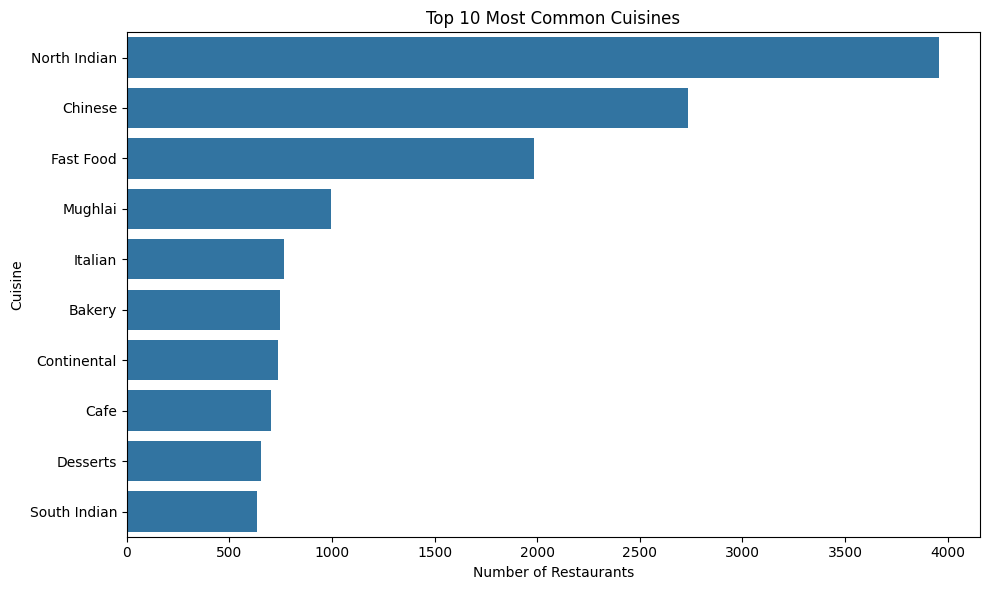

In [56]:
top_cuisines = cuisine_counts.head(10)

plt.figure(figsize=(10, 6))

sns.barplot(
    data=top_cuisines,
    x="Restaurant Count",
    y="Cuisine"
)

plt.title("Top 10 Most Common Cuisines")
plt.xlabel("Number of Restaurants")
plt.ylabel("Cuisine")

plt.tight_layout()
plt.show()

### Cuisine Popularity vs Customer Perception

Cuisine prevalence and average rating do not necessarily move together. Highly prevalent cuisines represent a larger portion of the restaurant market, but this does not automatically translate into higher customer ratings.

The analysis shows an approximately -0.40 correlation between cuisine prevalence and average rating, suggesting a moderate inverse relationship in this dataset.

In [57]:
top_10_share = (
    top_cuisines["Restaurant Count"].sum()
    / cuisine_counts["Restaurant Count"].sum()
    * 100
)

print(f"Top 10 cuisines account for {top_10_share:.2f}% of all cuisine associations.")

Top 10 cuisines account for 70.59% of all cuisine associations.


**Business Insight:**  
Highly prevalent cuisines such as North Indian, Chinese and Fast Food dominate restaurant supply, while several less prevalent cuisines achieve higher average ratings. This suggests that market popularity and customer satisfaction represent different dimensions and should be evaluated separately when assessing cuisine opportunities.

#### 5.2.1 Cuisine Popularity vs. Customer Ratings

In [58]:
# Calculate restaurant count and average rating by cuisine

cuisine_performance = (
    cuisine_df
    .merge(
        df[["Restaurant ID", "Rating for Analysis"]],
        on="Restaurant ID",
        how="left"
    )
    .groupby("Cuisines")
    .agg(
        Restaurant_Count=("Restaurant ID", "nunique"),
        Average_Rating=("Rating for Analysis", "mean")
    )
    .reset_index()
)

# Keep cuisines with sufficient representation
cuisine_performance = cuisine_performance[
    cuisine_performance["Restaurant_Count"] >= 50
].copy()

cuisine_performance["Average_Rating"] = (
    cuisine_performance["Average_Rating"].round(2)
)

cuisine_performance.sort_values(
    "Average_Rating",
    ascending=False
).head(15)

,Cuisines,Restaurant_Count,Average_Rating
65,Indian,70,4.16
116,Sandwich,53,4.07
87,Mediterranean,112,4.02
128,Steak,62,3.99
131,Sushi,75,3.97
48,European,148,3.96
118,Seafood,174,3.93
7,Asian,233,3.90
88,Mexican,181,3.87
72,Japanese,135,3.83


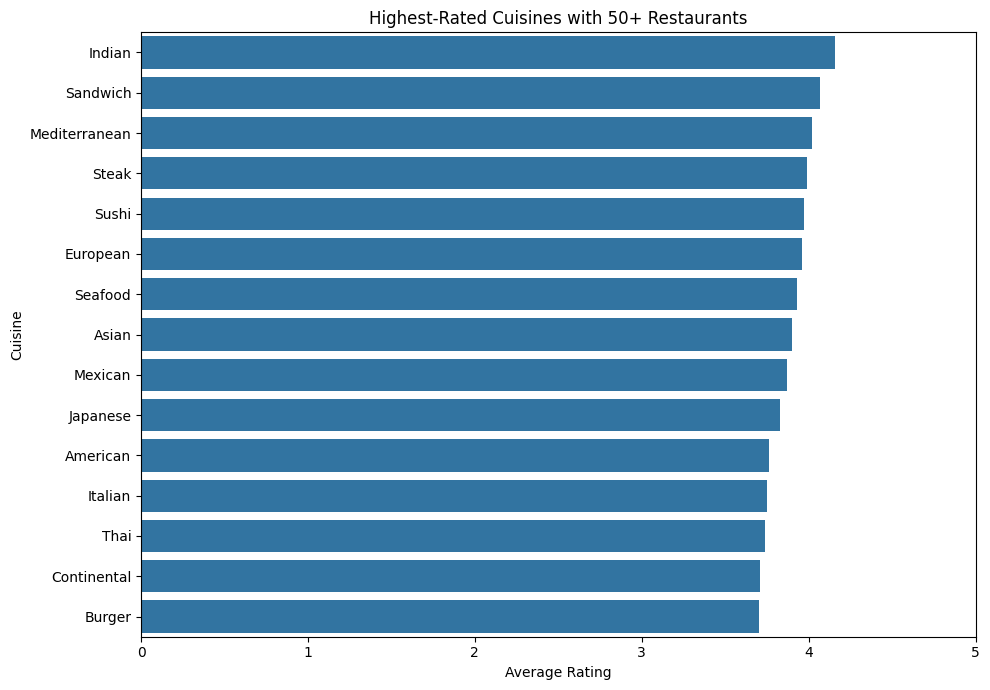

In [59]:
top_rated_cuisines = (
    cuisine_performance
    .sort_values("Average_Rating", ascending=False)
    .head(15)
)

plt.figure(figsize=(10, 7))

sns.barplot(
    data=top_rated_cuisines,
    x="Average_Rating",
    y="Cuisines"
)

plt.title("Highest-Rated Cuisines with 50+ Restaurants")
plt.xlabel("Average Rating")
plt.ylabel("Cuisine")
plt.xlim(0, 5)

plt.tight_layout()
plt.show()

#### 5.2.2 Cuisine Popularity vs. Average Rating

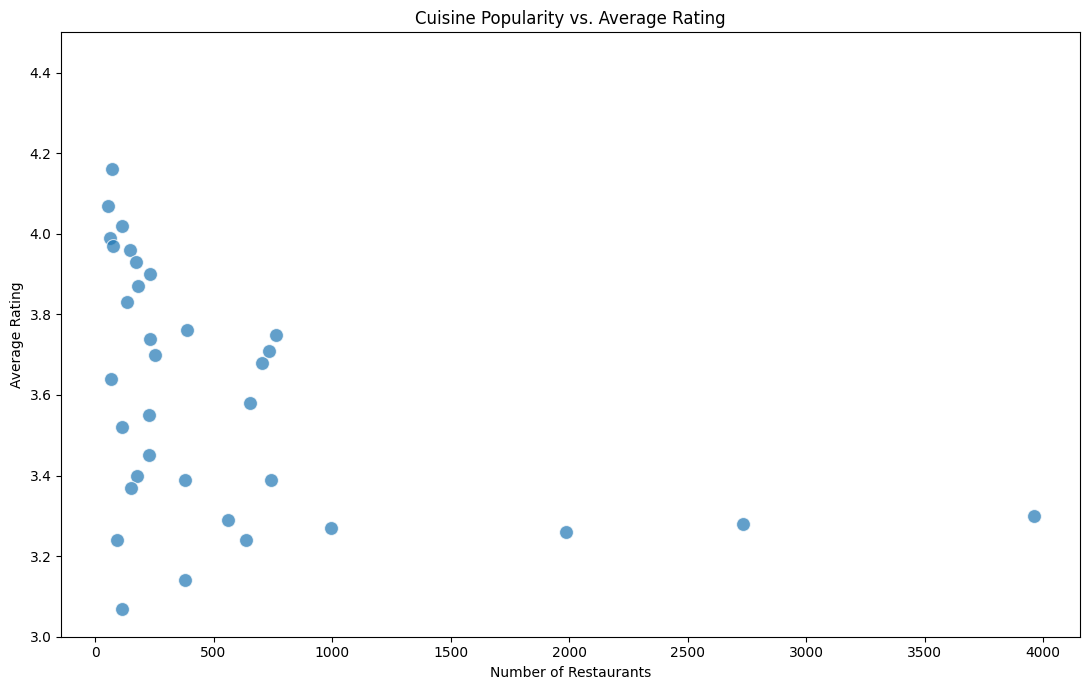

In [60]:
plt.figure(figsize=(11, 7))

sns.scatterplot(
    data=cuisine_performance,
    x="Restaurant_Count",
    y="Average_Rating",
    s=100,
    alpha=0.7
)

plt.title("Cuisine Popularity vs. Average Rating")
plt.xlabel("Number of Restaurants")
plt.ylabel("Average Rating")
plt.ylim(3, 4.5)

plt.tight_layout()
plt.show()

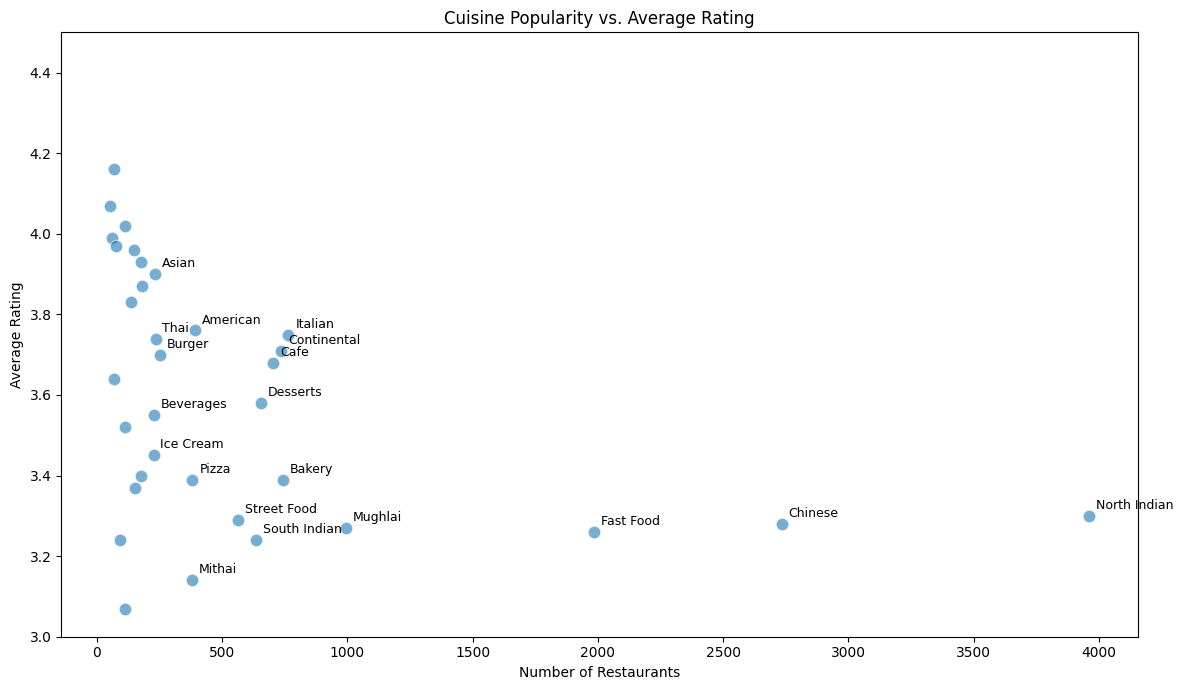

In [61]:
top_cuisines_for_label = cuisine_performance[
    cuisine_performance["Restaurant_Count"] >= 200
]

plt.figure(figsize=(12, 7))

sns.scatterplot(
    data=cuisine_performance,
    x="Restaurant_Count",
    y="Average_Rating",
    s=80,
    alpha=0.6
)

for _, row in top_cuisines_for_label.iterrows():
    plt.annotate(
        row["Cuisines"],
        (row["Restaurant_Count"], row["Average_Rating"]),
        xytext=(5, 5),
        textcoords="offset points",
        fontsize=9
    )

plt.title("Cuisine Popularity vs. Average Rating")
plt.xlabel("Number of Restaurants")
plt.ylabel("Average Rating")
plt.ylim(3, 4.5)

plt.tight_layout()
plt.show()

In [62]:
correlation = cuisine_performance[
    ["Restaurant_Count", "Average_Rating"]
].corr().iloc[0, 1]

print(f"Correlation between cuisine prevalence and average rating: {correlation:.2f}")

Correlation between cuisine prevalence and average rating: -0.40


Insight: Cuisine prevalence and average rating show a moderate negative association (r = −0.40), suggesting that highly prevalent cuisines do not necessarily correspond to higher customer ratings. However, this is an association at the cuisine level and should not be interpreted as a causal relationship.

### 5.3 Geographic Analysis

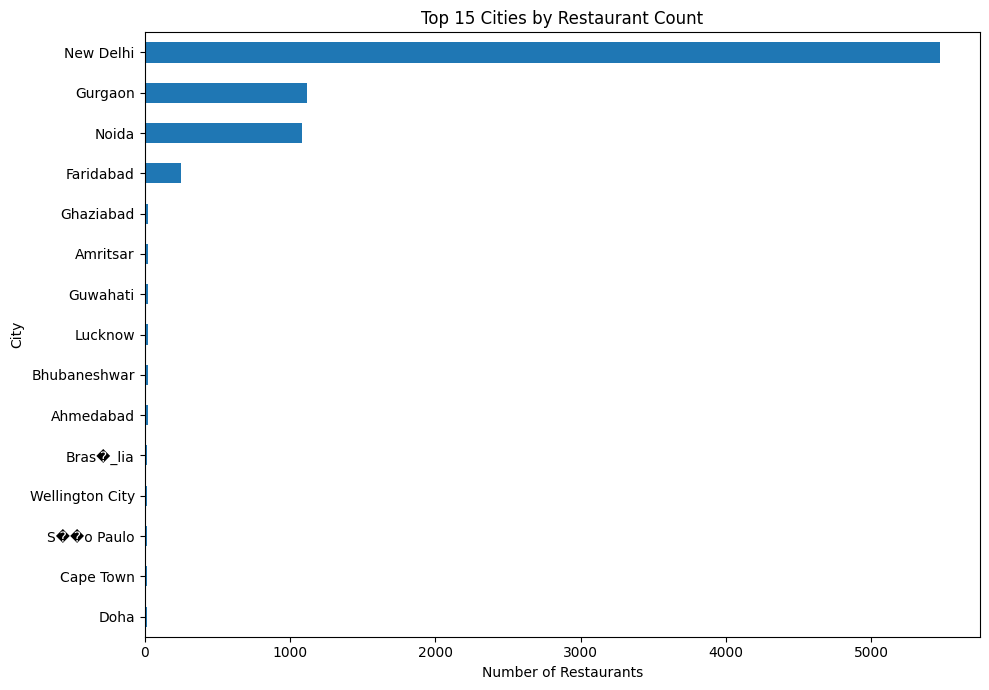

In [128]:
# Top 15 cities by restaurant count

top_cities = (
    df["City"]
    .value_counts()
    .head(15)
    .sort_values()
)

plt.figure(figsize=(10, 7))
top_cities.plot(kind="barh")

plt.title("Top 15 Cities by Restaurant Count")
plt.xlabel("Number of Restaurants")
plt.ylabel("City")
plt.tight_layout()
plt.show()

**Business Insight:**  
Restaurant distribution is highly concentrated geographically, with a small number of cities accounting for a large share of the dataset. New Delhi, Gurgaon and Noida together account for 80.39% of restaurant records, indicating that the dataset is particularly concentrated in the Delhi-NCR market.

In [63]:
city_analysis = (
    df.groupby("City")
    .agg(
        Restaurant_Count=("Restaurant ID", "nunique"),
        Average_Rating=("Rating for Analysis", "mean"),
        Total_Votes=("Votes", "sum"),
        Average_Votes=("Votes", "mean")
    )
    .reset_index()
)

city_analysis["Average_Rating"] = city_analysis["Average_Rating"].round(2)

city_analysis.sort_values(
    "Restaurant_Count",
    ascending=False
).head(15)

,City,Restaurant_Count,Average_Rating,Total_Votes,Average_Votes
87,New Delhi,5473,3.30,628340,114.807236
50,Gurgaon,1118,3.33,132160,118.211091
88,Noida,1080,3.16,73488,68.044444
43,Faridabad,251,3.10,6486,25.840637
48,Ghaziabad,25,3.10,2366,94.640000
17,Bhubaneshwar,21,3.98,4243,202.047619
51,Guwahati,21,4.19,4964,236.380952
69,Lucknow,21,4.20,9130,434.761905
2,Ahmedabad,21,4.16,12266,584.095238
5,Amritsar,21,3.69,3665,174.523810


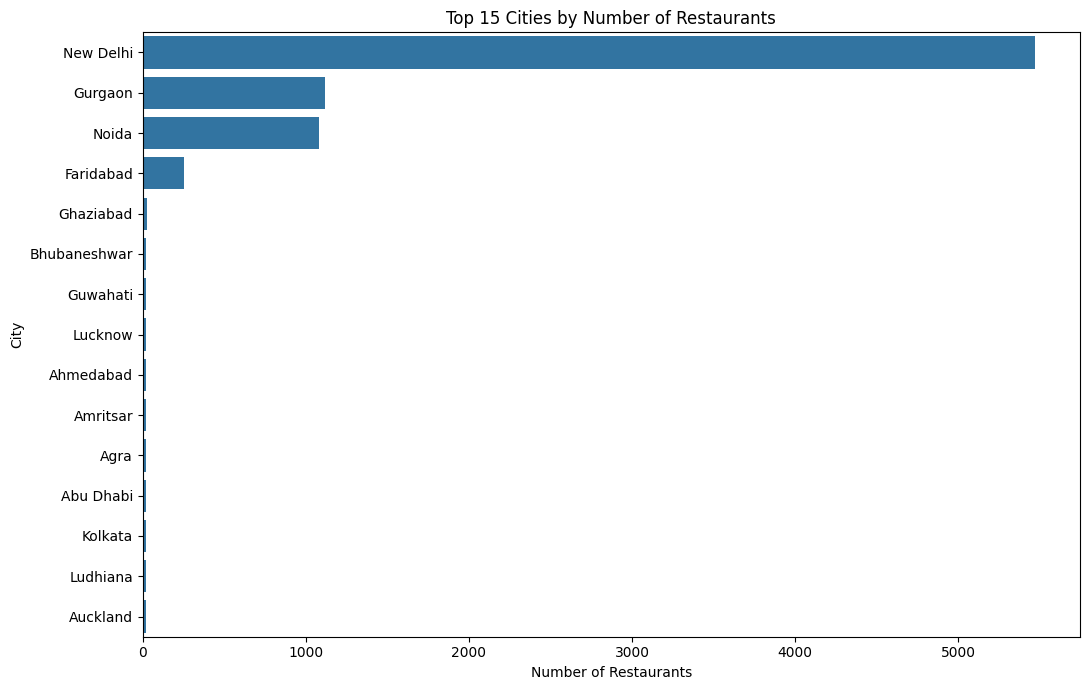

In [64]:
top_cities = (
    city_analysis
    .sort_values("Restaurant_Count", ascending=False)
    .head(15)
)

plt.figure(figsize=(11, 7))

sns.barplot(
    data=top_cities,
    x="Restaurant_Count",
    y="City"
)

plt.title("Top 15 Cities by Number of Restaurants")
plt.xlabel("Number of Restaurants")
plt.ylabel("City")

plt.tight_layout()
plt.show()

### Geographic Distribution of Restaurants

The geographic distribution highlights the concentration of restaurants across markets. The visualization helps identify major restaurant clusters and provides context for evaluating market concentration and expansion opportunities.

In [130]:
# Install the map dataset package
!pip -q install geodatasets

In [131]:
import geopandas as gpd
from geodatasets import get_path

# Load world map from the installed dataset
world = gpd.read_file(get_path("naturalearth.land"))

world.head()

,featurecla,scalerank,min_zoom,geometry
0,Land,1,1.0,"POLYGON ((-59.57209 -80.04018, -59.86585 -80.5..."
1,Land,1,1.0,"POLYGON ((-159.20818 -79.49706, -161.1276 -79...."
2,Land,1,0.0,"POLYGON ((-45.15476 -78.04707, -43.92083 -78.4..."
3,Land,1,1.0,"POLYGON ((-121.21151 -73.50099, -119.91885 -73..."
4,Land,1,1.0,"POLYGON ((-125.55957 -73.48135, -124.03188 -73..."


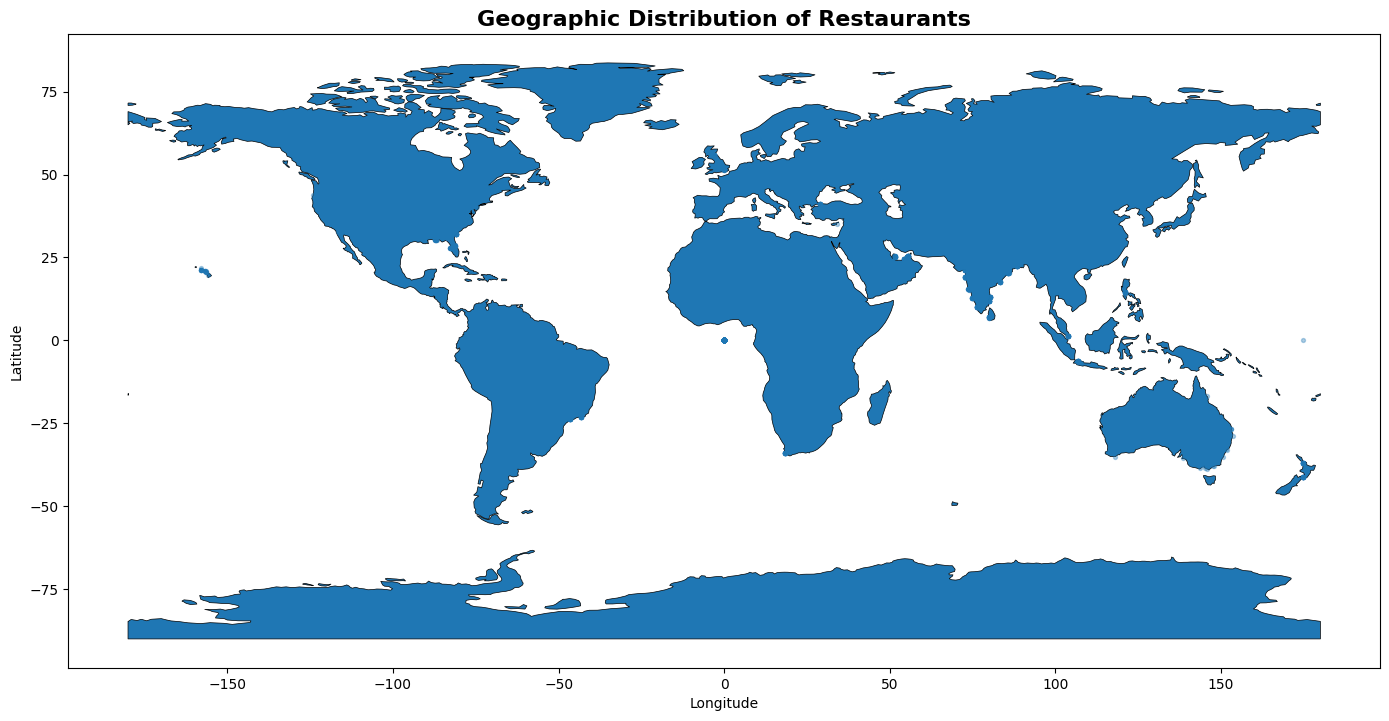

In [132]:
# Plot restaurant locations on a world map

fig, ax = plt.subplots(figsize=(14, 8))

# World basemap
world.plot(
    ax=ax,
    edgecolor="black",
    linewidth=0.5
)

# Restaurant locations
ax.scatter(
    df["Longitude"],
    df["Latitude"],
    s=8,
    alpha=0.35
)

ax.set_title(
    "Geographic Distribution of Restaurants",
    fontsize=16,
    fontweight="bold"
)

ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")

plt.tight_layout()
plt.show()

### Geographic Business Insight

Restaurant supply is highly concentrated across a small number of cities. New Delhi, Gurgaon and Noida together account for 80.39% of restaurant records in the dataset. This concentration should be considered when interpreting overall market trends, as findings may be strongly influenced by the Delhi-NCR market.

**Business Insight:**  
The restaurant dataset is geographically concentrated rather than evenly distributed across markets. This concentration suggests that market-level comparisons should account for differences in restaurant coverage across cities and countries.

### Market Concentration Insight

Restaurant supply is highly concentrated geographically. New Delhi, Gurgaon
and Noida together represent 80.39% of restaurant records, indicating that
the dataset is dominated by a small number of major urban markets.

From a business perspective, this concentration suggests that market-level
strategies should account for differences in restaurant density, competitive
intensity and consumer behavior across cities rather than treating the entire
dataset as a uniform market.

In [65]:
city_rating = city_analysis[
    city_analysis["Restaurant_Count"] >= 20
].sort_values(
    "Average_Rating",
    ascending=False
)

city_rating.head(15)

,City,Restaurant_Count,Average_Rating,Total_Votes,Average_Votes
67,London,20,4.54,8724,436.20
110,Rio de Janeiro,20,4.49,401,20.05
123,Tampa Bay,20,4.41,27407,1370.35
14,Bangalore,20,4.38,56115,2805.75
39,Dubai,20,4.37,18693,934.65
26,Chennai,20,4.31,27695,1384.75
0,Abu Dhabi,20,4.30,6045,302.25
6,Ankara,20,4.30,2627,131.35
9,Auckland,20,4.28,6795,339.75
63,Kolkata,20,4.26,44593,2229.65


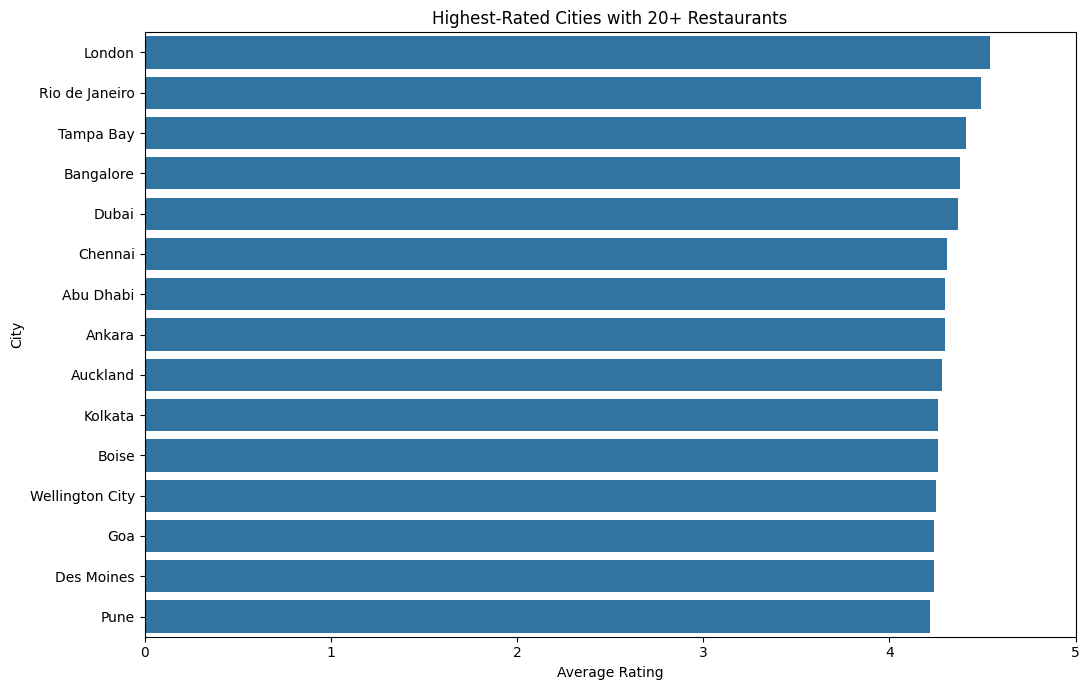

In [66]:
top_rated_cities = city_rating.head(15)

plt.figure(figsize=(11, 7))

sns.barplot(
    data=top_rated_cities,
    x="Average_Rating",
    y="City"
)

plt.title("Highest-Rated Cities with 20+ Restaurants")
plt.xlabel("Average Rating")
plt.ylabel("City")
plt.xlim(0, 5)

plt.tight_layout()
plt.show()

In [67]:
city_analysis["Restaurant_Count"].describe()

,Restaurant_Count
count,140.000000
mean,68.157143
std,478.407178
min,1.000000
25%,1.000000
50%,20.000000
75%,20.000000
max,5473.000000


In [68]:
print("Cities with 20+ restaurants:",
      (city_analysis["Restaurant_Count"] >= 20).sum())

print("Cities with 50+ restaurants:",
      (city_analysis["Restaurant_Count"] >= 50).sum())

print("Cities with 100+ restaurants:",
      (city_analysis["Restaurant_Count"] >= 100).sum())

Cities with 20+ restaurants: 71
Cities with 50+ restaurants: 4
Cities with 100+ restaurants: 4


In [69]:
total_restaurants = df["Restaurant ID"].nunique()

top_3_city_share = (
    city_analysis
    .nlargest(3, "Restaurant_Count")["Restaurant_Count"]
    .sum()
    / total_restaurants
    * 100
)

print(f"Top 3 cities account for {top_3_city_share:.2f}% of all restaurants.")

Top 3 cities account for 80.39% of all restaurants.


#### 5.3.1 City Market Concentration & Performance

In [70]:
city_performance = (
    city_analysis[
        city_analysis["Restaurant_Count"] >= 50
    ]
    .sort_values("Restaurant_Count", ascending=False)
    .copy()
)

city_performance

,City,Restaurant_Count,Average_Rating,Total_Votes,Average_Votes
87,New Delhi,5473,3.30,628340,114.807236
50,Gurgaon,1118,3.33,132160,118.211091
88,Noida,1080,3.16,73488,68.044444
43,Faridabad,251,3.10,6486,25.840637


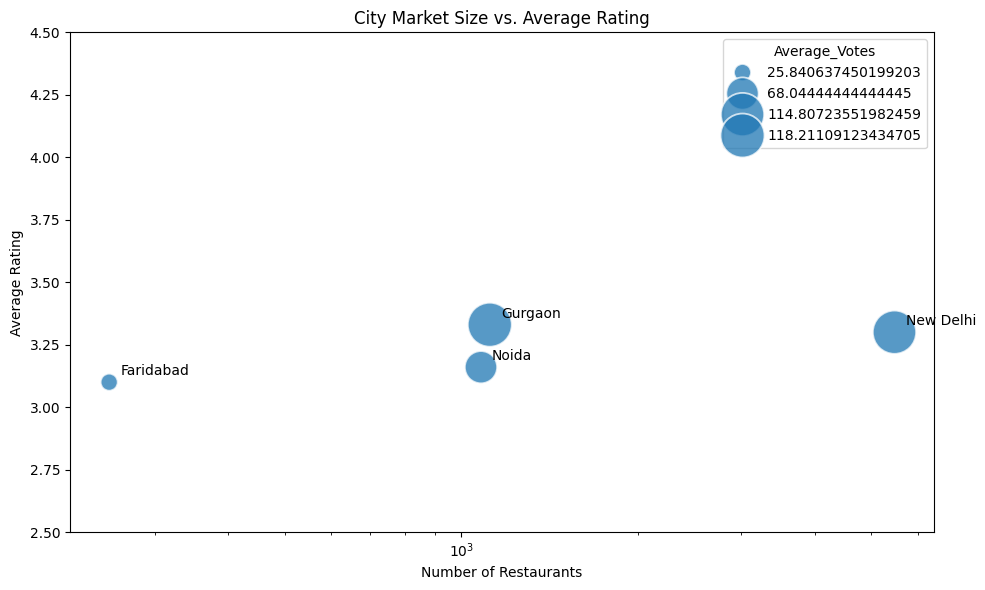

In [71]:
plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=city_performance,
    x="Restaurant_Count",
    y="Average_Rating",
    size="Average_Votes",
    sizes=(150, 1000),
    alpha=0.75
)

for _, row in city_performance.iterrows():
    plt.annotate(
        row["City"],
        (row["Restaurant_Count"], row["Average_Rating"]),
        xytext=(8, 5),
        textcoords="offset points"
    )

plt.title("City Market Size vs. Average Rating")
plt.xlabel("Number of Restaurants")
plt.ylabel("Average Rating")
plt.xscale("log")
plt.ylim(2.5, 4.5)

plt.tight_layout()
plt.show()

In [72]:
city_concentration = (
    city_analysis
    .sort_values("Restaurant_Count", ascending=False)
    .copy()
)

city_concentration["Cumulative_Share"] = (
    city_concentration["Restaurant_Count"].cumsum()
    / city_concentration["Restaurant_Count"].sum()
    * 100
)

city_concentration.head(10)

,City,Restaurant_Count,Average_Rating,Total_Votes,Average_Votes,Cumulative_Share
87,New Delhi,5473,3.30,628340,114.807236,57.356948
50,Gurgaon,1118,3.33,132160,118.211091,69.073569
88,Noida,1080,3.16,73488,68.044444,80.391951
43,Faridabad,251,3.10,6486,25.840637,83.022427
48,Ghaziabad,25,3.10,2366,94.640000,83.284427
17,Bhubaneshwar,21,3.98,4243,202.047619,83.504506
51,Guwahati,21,4.19,4964,236.380952,83.724586
69,Lucknow,21,4.20,9130,434.761905,83.944666
2,Ahmedabad,21,4.16,12266,584.095238,84.164745
5,Amritsar,21,3.69,3665,174.523810,84.384825


### 5.4 Pricing and Value Analysis

In [73]:
price_analysis = (
    df.groupby("Price range")
    .agg(
        Restaurant_Count=("Restaurant ID", "nunique"),
        Average_Rating=("Rating for Analysis", "mean"),
        Average_Votes=("Votes", "mean"),
        Total_Votes=("Votes", "sum")
    )
    .reset_index()
)

price_analysis["Average_Rating"] = price_analysis["Average_Rating"].round(2)
price_analysis["Average_Votes"] = price_analysis["Average_Votes"].round(2)

price_analysis

,Price range,Restaurant_Count,Average_Rating,Average_Votes,Total_Votes
0,1,4438,3.24,44.37,196934
1,2,3113,3.38,147.61,459501
2,3,1405,3.78,443.76,623487
3,4,586,3.89,368.60,215997


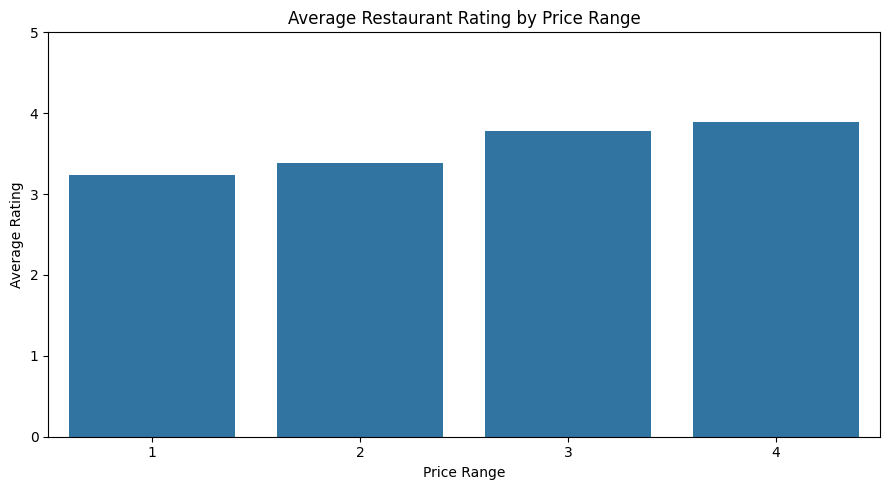

In [74]:
plt.figure(figsize=(9, 5))

sns.barplot(
    data=price_analysis,
    x="Price range",
    y="Average_Rating"
)

plt.title("Average Restaurant Rating by Price Range")
plt.xlabel("Price Range")
plt.ylabel("Average Rating")
plt.ylim(0, 5)

plt.tight_layout()
plt.show()

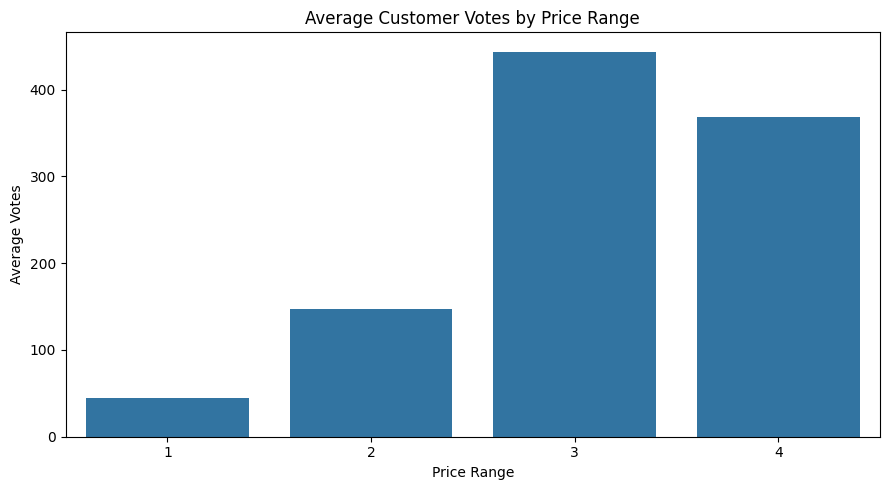

In [75]:
plt.figure(figsize=(9, 5))

sns.barplot(
    data=price_analysis,
    x="Price range",
    y="Average_Votes"
)

plt.title("Average Customer Votes by Price Range")
plt.xlabel("Price Range")
plt.ylabel("Average Votes")

plt.tight_layout()
plt.show()

In [76]:
price_rating_corr = df[
    ["Price range", "Rating for Analysis"]
].corr().iloc[0, 1]

print(
    f"Correlation between price range and restaurant rating: "
    f"{price_rating_corr:.2f}"
)

Correlation between price range and restaurant rating: 0.40


In [77]:
price_votes_corr = df[
    ["Price range", "Votes"]
].corr().iloc[0, 1]

print(
    f"Correlation between price range and customer votes: "
    f"{price_votes_corr:.2f}"
)

Correlation between price range and customer votes: 0.31


In [78]:
price_rating_spearman = df[
    ["Price range", "Rating for Analysis"]
].corr(method="spearman").iloc[0, 1]

price_votes_spearman = df[
    ["Price range", "Votes"]
].corr(method="spearman").iloc[0, 1]

print(f"Spearman correlation — Price vs Rating: {price_rating_spearman:.2f}")
print(f"Spearman correlation — Price vs Votes: {price_votes_spearman:.2f}")

Spearman correlation — Price vs Rating: 0.40
Spearman correlation — Price vs Votes: 0.55


### Pricing, Customer Perception & Engagement

The analysis indicates a positive association between restaurant price range and both customer ratings and engagement. Average rating increases from 3.24 in Price Range 1 to 3.89 in Price Range 4, while higher price ranges also receive more customer votes on average.

However, these relationships should be interpreted as associations rather than causal effects. Higher-priced restaurants may differ from lower-priced restaurants in other factors such as cuisine, location, service offerings and restaurant positioning.

**Business Insight:**  
Premium-priced restaurants in the dataset tend to receive stronger ratings and greater customer engagement. For restaurant businesses, this suggests that pricing should be evaluated alongside perceived value, service quality and customer experience rather than treated as an isolated factor.

### 5.5 Digital Service Adoption Analysis

In [79]:
service_analysis = (
    df.groupby(["Has Online delivery", "Has Table booking"])
    .agg(
        Restaurant_Count=("Restaurant ID", "nunique"),
        Average_Rating=("Rating for Analysis", "mean"),
        Average_Votes=("Votes", "mean")
    )
    .reset_index()
)

service_analysis["Average_Rating"] = service_analysis["Average_Rating"].round(2)
service_analysis["Average_Votes"] = service_analysis["Average_Votes"].round(2)

service_analysis

,Has Online delivery,Has Table booking,Restaurant_Count,Average_Rating,Average_Votes
0,No,No,6368,3.45,121.77
1,No,Yes,723,3.57,280.19
2,Yes,No,2016,3.33,154.56
3,Yes,Yes,435,3.61,474.30


In [80]:
delivery_analysis = (
    df.groupby("Has Online delivery")
    .agg(
        Restaurant_Count=("Restaurant ID", "nunique"),
        Average_Rating=("Rating for Analysis", "mean"),
        Average_Votes=("Votes", "mean")
    )
    .reset_index()
)

delivery_analysis["Average_Rating"] = delivery_analysis["Average_Rating"].round(2)
delivery_analysis["Average_Votes"] = delivery_analysis["Average_Votes"].round(2)

delivery_analysis

,Has Online delivery,Restaurant_Count,Average_Rating,Average_Votes
0,No,7091,3.47,137.92
1,Yes,2451,3.38,211.31


In [81]:
service_analysis["Service Configuration"] = (
    service_analysis["Has Online delivery"]
    + " Delivery / "
    + service_analysis["Has Table booking"]
    + " Booking"
)

service_analysis

,Has Online delivery,Has Table booking,Restaurant_Count,Average_Rating,Average_Votes,Service Configuration
0,No,No,6368,3.45,121.77,No Delivery / No Booking
1,No,Yes,723,3.57,280.19,No Delivery / Yes Booking
2,Yes,No,2016,3.33,154.56,Yes Delivery / No Booking
3,Yes,Yes,435,3.61,474.30,Yes Delivery / Yes Booking


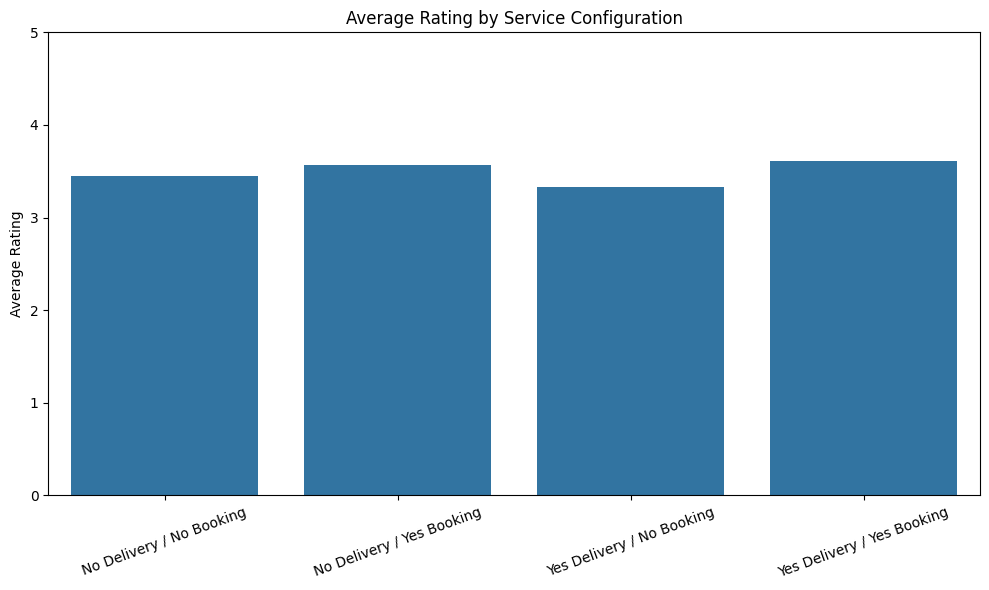

In [82]:
plt.figure(figsize=(10, 6))

sns.barplot(
    data=service_analysis,
    x="Service Configuration",
    y="Average_Rating"
)

plt.title("Average Rating by Service Configuration")
plt.xlabel("")
plt.ylabel("Average Rating")
plt.ylim(0, 5)
plt.xticks(rotation=20)

plt.tight_layout()
plt.show()

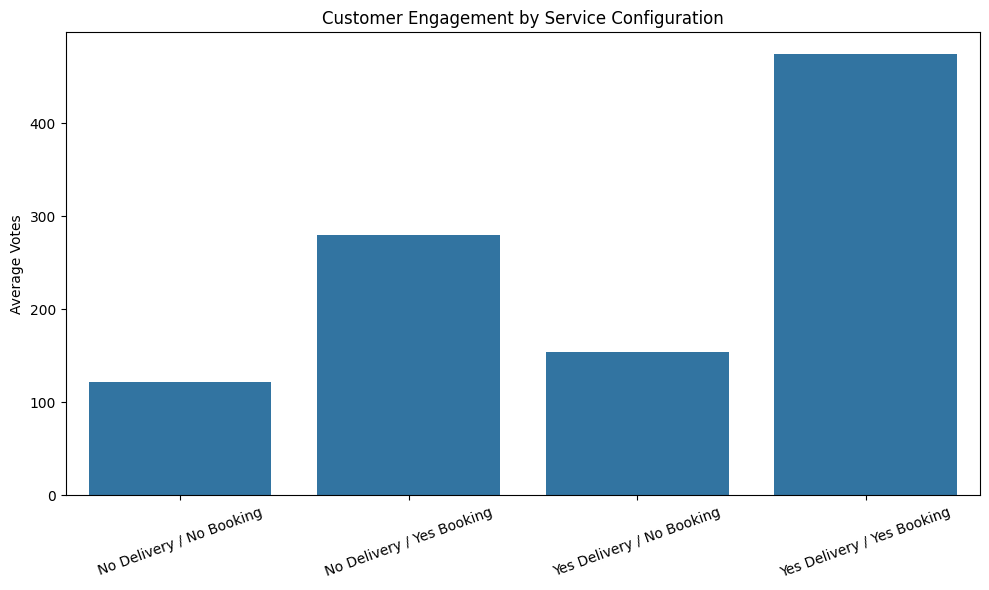

In [83]:
plt.figure(figsize=(10, 6))

sns.barplot(
    data=service_analysis,
    x="Service Configuration",
    y="Average_Votes"
)

plt.title("Customer Engagement by Service Configuration")
plt.xlabel("")
plt.ylabel("Average Votes")
plt.xticks(rotation=20)

plt.tight_layout()
plt.show()

In [84]:
delivery_adoption = (
    df["Has Online delivery"].eq("Yes").mean() * 100
)

booking_adoption = (
    df["Has Table booking"].eq("Yes").mean() * 100
)

both_adoption = (
    (
        (df["Has Online delivery"] == "Yes") &
        (df["Has Table booking"] == "Yes")
    ).mean() * 100
)

print(f"Online delivery adoption: {delivery_adoption:.2f}%")
print(f"Table booking adoption: {booking_adoption:.2f}%")
print(f"Both services adoption: {both_adoption:.2f}%")

Online delivery adoption: 25.69%
Table booking adoption: 12.14%
Both services adoption: 4.56%


### Digital Service Adoption & Customer Engagement

Digital service adoption varies substantially across restaurants. While online delivery is more common than table booking, restaurants offering both services record the highest average customer engagement in the dataset.

This suggests that a broader digital service proposition may be associated with stronger customer interaction. However, the relationship should be interpreted as an association rather than evidence that offering both services directly causes higher engagement.

**Business Insight:**  
Restaurants can view online delivery and table booking as complementary customer touchpoints. The relatively low adoption of both services (4.56%) indicates that the combined service configuration is less common in the dataset, while its higher average votes indicate stronger customer engagement among restaurants using both services.

### 5.6 Restaurant Chain Analysis

In [85]:
chain_analysis = (
    df.groupby("Restaurant Name")
    .agg(
        Outlet_Count=("Restaurant ID", "nunique"),
        Average_Rating=("Rating for Analysis", "mean"),
        Total_Votes=("Votes", "sum"),
        Average_Votes=("Votes", "mean")
    )
    .reset_index()
)

chain_analysis = chain_analysis.sort_values(
    "Outlet_Count",
    ascending=False
)

chain_analysis.head(20)

,Restaurant Name,Outlet_Count,Average_Rating,Total_Votes,Average_Votes
1098,Cafe Coffee Day,83,2.997015,2428,29.253012
2096,Domino's Pizza,79,2.925676,6643,84.088608
6098,Subway,63,3.003279,6124,97.206349
2713,Green Chick Chop,51,3.097727,964,18.901961
4070,McDonald's,48,3.410638,5291,110.229167
3472,Keventers,34,3.365517,1263,37.147059
4953,Pizza Hut,30,3.434483,4961,165.366667
2616,Giani,29,3.250000,854,29.448276
680,Baskin Robbins,28,3.256250,428,15.285714
663,Barbeque Nation,26,4.353846,28142,1082.384615


In [86]:
multi_location = chain_analysis[
    chain_analysis["Outlet_Count"] >= 5
].copy()

print(
    f"Number of restaurant brands with 5+ outlets: "
    f"{len(multi_location)}"
)

Number of restaurant brands with 5+ outlets: 112


In [87]:
multi_location.head(20)

,Restaurant Name,Outlet_Count,Average_Rating,Total_Votes,Average_Votes
1098,Cafe Coffee Day,83,2.997015,2428,29.253012
2096,Domino's Pizza,79,2.925676,6643,84.088608
6098,Subway,63,3.003279,6124,97.206349
2713,Green Chick Chop,51,3.097727,964,18.901961
4070,McDonald's,48,3.410638,5291,110.229167
3472,Keventers,34,3.365517,1263,37.147059
4953,Pizza Hut,30,3.434483,4961,165.366667
2616,Giani,29,3.250000,854,29.448276
680,Baskin Robbins,28,3.256250,428,15.285714
663,Barbeque Nation,26,4.353846,28142,1082.384615


### Restaurant Chain Scale & Performance

Restaurant chain scale shows only weak relationships with customer outcomes. The Spearman correlation between outlet count and average rating is 0.10, while the correlation between outlet count and average votes is 0.08.

This indicates that expanding the number of outlets alone is not strongly associated with higher ratings or greater average customer engagement in this dataset.

**Business Insight:**  
For restaurant chains, scale and customer experience appear to represent different dimensions of performance. Expansion should therefore be evaluated alongside factors such as service quality, consistency, location, pricing and customer experience rather than outlet count alone.

#### 5.6.1 Multi-Location Restaurant Brand Performance

In [88]:
chain_performance = (
    chain_analysis[
        chain_analysis["Outlet_Count"] >= 10
    ]
    .copy()
)

print(
    f"Restaurant brands with 10+ recorded outlets: "
    f"{len(chain_performance)}"
)

chain_performance.head(20)

Restaurant brands with 10+ recorded outlets: 40


,Restaurant Name,Outlet_Count,Average_Rating,Total_Votes,Average_Votes
1098,Cafe Coffee Day,83,2.997015,2428,29.253012
2096,Domino's Pizza,79,2.925676,6643,84.088608
6098,Subway,63,3.003279,6124,97.206349
2713,Green Chick Chop,51,3.097727,964,18.901961
4070,McDonald's,48,3.410638,5291,110.229167
3472,Keventers,34,3.365517,1263,37.147059
4953,Pizza Hut,30,3.434483,4961,165.366667
2616,Giani,29,3.250000,854,29.448276
680,Baskin Robbins,28,3.256250,428,15.285714
663,Barbeque Nation,26,4.353846,28142,1082.384615


In [89]:
chain_correlation = chain_performance[
    ["Outlet_Count", "Average_Rating"]
].corr(method="spearman").iloc[0, 1]

print(
    f"Spearman correlation between outlet count and average rating: "
    f"{chain_correlation:.2f}"
)

Spearman correlation between outlet count and average rating: 0.10


In [90]:
chain_votes_correlation = chain_performance[
    ["Outlet_Count", "Average_Votes"]
].corr(method="spearman").iloc[0, 1]

print(
    f"Spearman correlation between outlet count and average votes: "
    f"{chain_votes_correlation:.2f}"
)

Spearman correlation between outlet count and average votes: 0.08


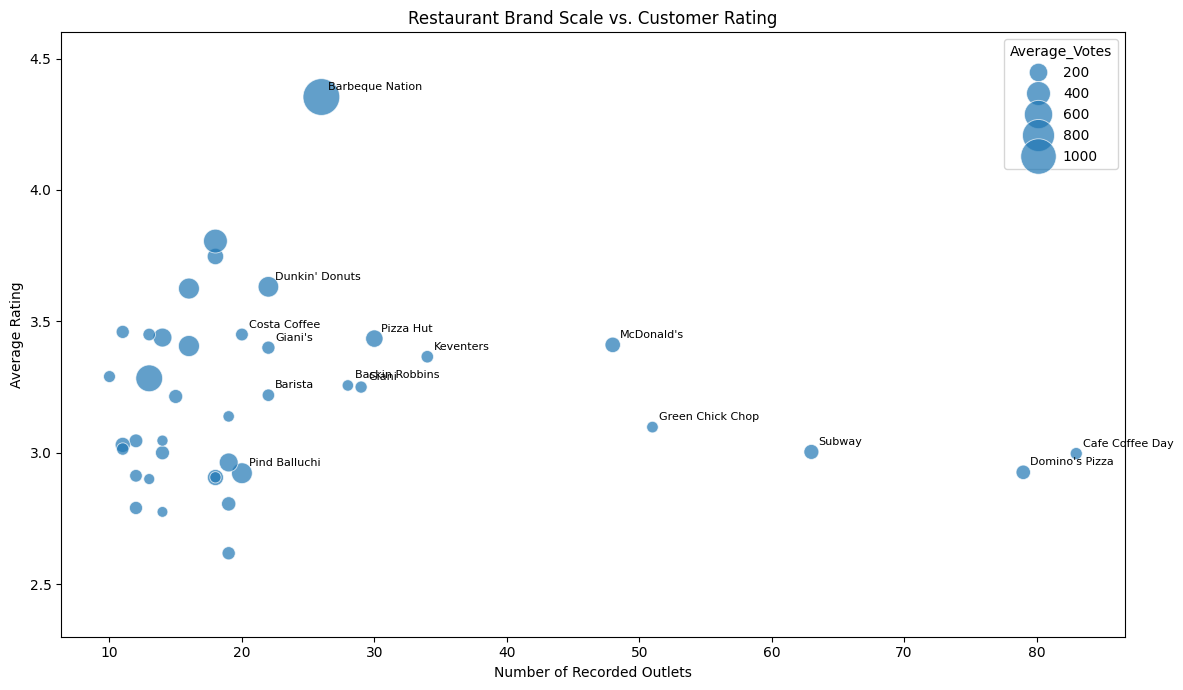

In [91]:
plt.figure(figsize=(12, 7))

sns.scatterplot(
    data=chain_performance,
    x="Outlet_Count",
    y="Average_Rating",
    size="Average_Votes",
    sizes=(60, 700),
    alpha=0.7
)

# Label brands with 20+ outlets
brands_to_label = chain_performance[
    chain_performance["Outlet_Count"] >= 20
]

for _, row in brands_to_label.iterrows():
    plt.annotate(
        row["Restaurant Name"],
        (row["Outlet_Count"], row["Average_Rating"]),
        xytext=(5, 5),
        textcoords="offset points",
        fontsize=8
    )

plt.title("Restaurant Brand Scale vs. Customer Rating")
plt.xlabel("Number of Recorded Outlets")
plt.ylabel("Average Rating")
plt.ylim(2.3, 4.6)

plt.tight_layout()
plt.show()

In [92]:
high_rated_chains = (
    chain_performance[
        chain_performance["Outlet_Count"] >= 10
    ]
    .sort_values("Average_Rating", ascending=False)
)

high_rated_chains.head(15)

,Restaurant Name,Outlet_Count,Average_Rating,Total_Votes,Average_Votes
663,Barbeque Nation,26,4.353846,28142,1082.384615
6072,Starbucks,18,3.805556,7139,396.611111
1324,Chaayos,18,3.747059,2473,137.388889
2142,Dunkin' Donuts,22,3.631579,5974,271.545455
2820,Haldiram's,16,3.625000,4525,282.812500
1029,Burger Point,11,3.460000,574,52.181818
701,Behrouz Biryani,13,3.450000,509,39.153846
1756,Costa Coffee,20,3.450000,861,43.050000
821,Bikanervala,14,3.438462,2980,212.857143
4953,Pizza Hut,30,3.434483,4961,165.366667


## 6. Statistical Validation

In [93]:
from scipy.stats import kruskal


In [94]:
price_groups = [
    group["Rating for Analysis"].dropna()
    for _, group in df.groupby("Price range")
]

kruskal_stat, kruskal_p = kruskal(*price_groups)

print(f"Kruskal-Wallis statistic: {kruskal_stat:.2f}")
print(f"p-value: {kruskal_p:.6f}")

Kruskal-Wallis statistic: 1326.24
p-value: 0.000000


In [95]:
from scipy.stats import mannwhitneyu

delivery_yes = df.loc[
    df["Has Online delivery"] == "Yes",
    "Rating for Analysis"
].dropna()

delivery_no = df.loc[
    df["Has Online delivery"] == "No",
    "Rating for Analysis"
].dropna()

u_stat, u_p = mannwhitneyu(
    delivery_yes,
    delivery_no,
    alternative="two-sided"
)

print(f"Mann-Whitney U statistic: {u_stat:.2f}")
print(f"p-value: {u_p:.6f}")

Mann-Whitney U statistic: 5653775.50
p-value: 0.001057


In [96]:
!pip -q install scikit-posthocs

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.4/46.4 kB 1.6 MB/s eta 0:00:00


In [97]:
import scikit_posthocs as sp

In [98]:
price_rating_data = df[
    ["Price range", "Rating for Analysis"]
].dropna()

dunn_results = sp.posthoc_dunn(
    price_rating_data,
    val_col="Rating for Analysis",
    group_col="Price range",
    p_adjust="bonferroni"
)

dunn_results

,1,2,3,4
1,1.000000e+00,1.325989e-26,8.865765e-204,5.835590e-145
2,1.325989e-26,1.000000e+00,9.215083e-103,4.090595e-82
3,8.865765e-204,9.215083e-103,1.000000e+00,3.934159e-03
4,5.835590e-145,4.090595e-82,3.934159e-03,1.000000e+00


In [99]:
dunn_results.round(4)

,1,2,3,4
1,1.0,0.0,0.0000,0.0000
2,0.0,1.0,0.0000,0.0000
3,0.0,0.0,1.0000,0.0039
4,0.0,0.0,0.0039,1.0000


### Statistical Validation of Observed Differences

Statistical tests were used to determine whether observed differences between restaurant groups are likely to reflect systematic differences rather than random variation.

The Kruskal–Wallis test indicates statistically significant differences in rating distributions across price ranges (p < 0.001). Pairwise comparisons further indicate significant differences between several price groups.

Similarly, the Mann–Whitney U test indicates a statistically significant difference between the rating distributions of restaurants with and without online delivery (p = 0.001057).

These results establish statistical association between the examined restaurant characteristics and rating distributions, but they do not establish causality.

**Business Interpretation:**  
The statistical evidence strengthens the descriptive findings by showing that differences in ratings across price segments and delivery configurations are unlikely to be explained solely by random variation. However, other factors such as city, cuisine, restaurant positioning and service quality may also contribute to these differences.

## 7. Key Business Findings



| Business Area | Key Finding | Business Implication |
|---|---|---|
| Geographic Concentration | New Delhi, Gurgaon and Noida account for 80.39% of restaurant records. | Overall market trends are strongly influenced by Delhi-NCR and should be interpreted with geographic concentration in mind. |
| Cuisine Concentration | The top 10 cuisines represent 70.59% of all cuisine associations. | Restaurant supply is concentrated around a limited number of cuisine categories. |
| Cuisine & Ratings | Cuisine prevalence and average rating show an approximately -0.40 association. | Market popularity and customer perception should be evaluated as separate dimensions. |
| Pricing | Average rating increases from 3.24 in Price Range 1 to 3.89 in Price Range 4. | Higher-priced restaurants in the dataset tend to receive stronger ratings, although this is an association rather than a causal relationship. |
| Customer Engagement | Higher price ranges generally receive greater customer engagement. | Pricing, perceived value and customer experience should be considered together. |
| Digital Services | Online delivery is available at 25.69% of restaurants, while only 4.56% offer both delivery and table booking. | Digital service adoption remains uneven across restaurants. |
| Service Combination | Restaurants offering both delivery and table booking have the highest average engagement at 474.30 votes. | Multiple digital touchpoints are associated with stronger customer engagement. |
| Restaurant Chain Scale | Outlet count has a weak association with average rating (Spearman = 0.10). | Expanding outlet count alone does not strongly correspond with better customer ratings. |
| Data Quality | 2,148 restaurants have no recorded rating and are treated as Not Rated. | Rating-based decisions should exclude unrated restaurants to avoid misleading conclusions. |

## 8. Business Recommendations


Based on the descriptive analysis, correlation analysis and statistical testing, the following business actions can be considered:

### 1. Prioritize high-density markets while accounting for concentration risk
New Delhi, Gurgaon and Noida account for 80.39% of restaurant records. Businesses operating in these markets can benefit from deeper market segmentation, while expansion decisions should avoid assuming that trends observed in Delhi-NCR represent all markets.

### 2. Segment cuisine strategy using both demand and customer perception
The restaurant landscape is concentrated around cuisines such as North Indian, Chinese and Fast Food, while several less prevalent cuisines show higher average ratings. Businesses can therefore evaluate cuisine opportunities using both market prevalence and customer ratings rather than relying on popularity alone.

### 3. Align pricing with perceived customer value
Higher price ranges are associated with higher average ratings and customer engagement. Restaurants should evaluate pricing alongside service quality, cuisine positioning and customer experience to ensure that higher prices are supported by perceived value.

### 4. Strengthen digital service integration
Only 4.56% of restaurants offer both online delivery and table booking, while restaurants with both services show the highest average engagement. Businesses can evaluate an integrated digital-service proposition to provide customers with multiple engagement and transaction touchpoints.

### 5. Focus on customer experience alongside chain expansion
The weak relationship between outlet count and average rating suggests that increasing the number of outlets alone is not strongly associated with better customer ratings. Restaurant chains should therefore prioritize consistency, service quality and customer experience alongside expansion.

## 9. Strategic Recommendations

Based on the descriptive, correlation and statistical analysis, the following strategic recommendations emerge:

### 1. Prioritize High-Density Markets

New Delhi, Gurgaon and Noida account for 80.39% of restaurant records, indicating a highly concentrated market. Businesses should prioritize these markets for competitive benchmarking, customer segmentation and demand analysis while carefully assessing market saturation before further expansion.

### 2. Build Differentiation Beyond High-Volume Cuisines

North Indian, Chinese and Fast Food represent the most prevalent cuisine categories, while cuisine prevalence and average rating show an approximately -0.40 association. This suggests that high market presence does not necessarily correspond with higher ratings. Restaurants should therefore focus on differentiated positioning, food quality and customer experience rather than competing solely within high-volume categories.

### 3. Align Pricing With Perceived Value

Average ratings increase from 3.24 in Price Range 1 to 3.89 in Price Range 4, while customer engagement is also higher in the upper price segments. Businesses should therefore evaluate premium positioning where supported by service quality, product differentiation and customer experience. Pricing decisions should be based on perceived value rather than price level alone.

### 4. Expand Digital Service Capabilities Strategically

Online delivery is available at 25.69% of restaurants, while table booking is available at 12.14%. This relatively limited adoption creates an opportunity for restaurants to strengthen digital customer touchpoints. However, the analysis does not establish that digital adoption directly causes higher ratings, so implementation should be evaluated alongside customer demand and operating economics.

### 5. Integrate Delivery and Table Booking

Only 4.56% of restaurants offer both online delivery and table booking, while this group records the highest average engagement at 474.30 votes. Restaurants can evaluate integrated service models that address both at-home ordering and dine-in discovery, using customer engagement and conversion metrics to measure effectiveness.

### 6. Scale With Consistent Customer Experience

Restaurant outlet count has only a weak association with average rating (Spearman = 0.10). This indicates that increasing outlet count alone is not strongly associated with better ratings. Restaurant chains should therefore complement expansion with standardized operating processes, service-quality monitoring and customer-experience controls.

### 7. Explore Underserved Segments Through Data-Led Validation

The strong concentration across both geography and cuisine indicates potential whitespace in less concentrated markets and differentiated cuisine segments. Before entering these segments, businesses should validate local demand, competitive intensity, pricing potential and customer preferences rather than relying solely on overall dataset patterns.

> **Managerial Takeaway:** Sustainable restaurant growth should combine market selection, differentiated positioning, value-based pricing, digital service integration and consistent customer experience. The analysis suggests that scale alone is not sufficient; growth decisions should be supported by customer engagement, ratings and market-level evidence.

## 10. Conclusion

This project analyzes 9,551 restaurant records to identify patterns in
market concentration, cuisine preferences, pricing, customer engagement,
digital service adoption, geographic distribution, and restaurant-chain
performance.

Key findings include:

- North Indian, Chinese and Fast Food are the three most prevalent cuisines.
- The top three cities account for 80.39% of restaurant records.
- Price Range 1 and 2 together represent 79.13% of restaurants.
- Price range is positively associated with both ratings and customer
  engagement, with stronger engagement differences across price segments.
- Online delivery is available at 25.69% of restaurants, while table booking
  is available at 12.14%.
- Table booking is substantially more prevalent among higher-priced
  restaurants, whereas online delivery does not follow a linear price pattern.
- Restaurant chain scale has only a weak association with average rating.
- Among rated restaurants, votes and ratings show a moderate positive
  association (r = 0.409).

The analysis combines exploratory data analysis, segmentation, correlation
analysis and non-parametric statistical testing to translate restaurant
data into actionable market insights.